In [ ]:
### Database Connection Setup
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="Thunder@2026"
)


In [2]:
### Country-Wise Revenue Summary
query = "SELECT Country, SUM(Revenue) FROM retail_transactions GROUP BY Country"

df = pd.read_sql(query, conn)
df.head()


C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\2775613975.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,country,sum
0,Australia,138521.31
1,Austria,10198.68
2,Bahrain,548.40
3,Belgium,41196.34
4,Brazil,1143.60


In [3]:
### Loading Retail Transactions Data
query = "SELECT * FROM retail_transactions"

df = pd.read_sql(query, conn)

df.head()

C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\2128058419.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands,15.0
1,536425,79321,CHILLI LIGHTS,8,2010-12-01 12:08:00,4.95,13758.0,United Kingdom,39.6
2,536522,47599A,PINK PARTY BAGS,1,2010-12-01 12:49:00,2.10,15012.0,United Kingdom,2.1
3,536601,22633,HAND WARMER UNION JACK,6,2010-12-02 08:33:00,1.85,17850.0,United Kingdom,11.1
4,536861,POST,POSTAGE,3,2010-12-03 10:44:00,18.00,12427.0,Germany,54.0


In [4]:
### Country-Wise Revenue Aggregation
query = """
SELECT Country, SUM(Quantity * UnitPrice) AS Revenue
FROM retail_transactions
GROUP BY Country
"""

df_country = pd.read_sql(query, conn)

df_country.head()

C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\3352105491.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_country = pd.read_sql(query, conn)


,country,revenue
0,Australia,138521.31
1,Austria,10198.68
2,Bahrain,548.40
3,Belgium,41196.34
4,Brazil,1143.60


In [5]:
### Transaction-Level Revenue Calculation
query = """
SELECT Quantity * UnitPrice AS Revenue
FROM retail_transactions
"""

df_revenue = pd.read_sql(query, conn)
df_revenue.head()

C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\3720257703.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue = pd.read_sql(query, conn)


,revenue
0,15.0
1,39.6
2,2.1
3,11.1
4,54.0


In [6]:
### Inspecting Revenue Data
print('Columns:', df_revenue.columns.tolist())
print(df_revenue.head())

Columns: ['revenue']
   revenue
0     15.0
1     39.6
2      2.1
3     11.1
4     54.0


Revenue Distribution Analysis

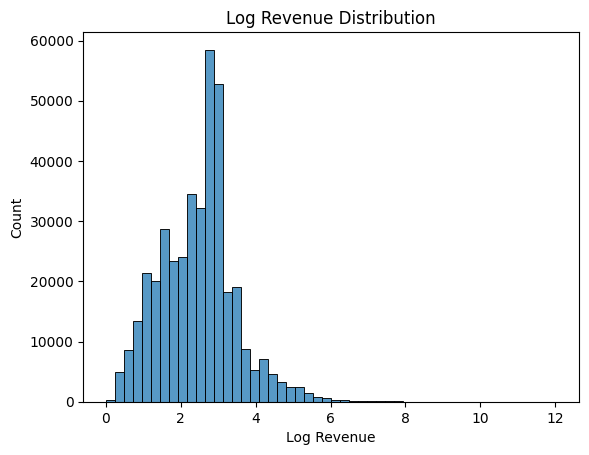

In [7]:
### Log-Transformed Revenue Distribution
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(np.log1p(df_revenue["revenue"]), bins=50)

plt.title("Log Revenue Distribution")
plt.xlabel("Log Revenue")

plt.show()

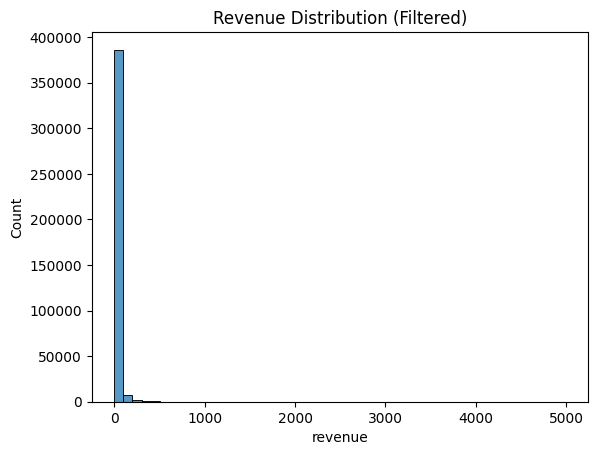

In [8]:
### Filtered Revenue Distribution
filtered = df_revenue[df_revenue["revenue"] < 5000]

sns.histplot(filtered["revenue"], bins=50)

plt.title("Revenue Distribution (Filtered)")
plt.show()

Country-wise sales Visualization

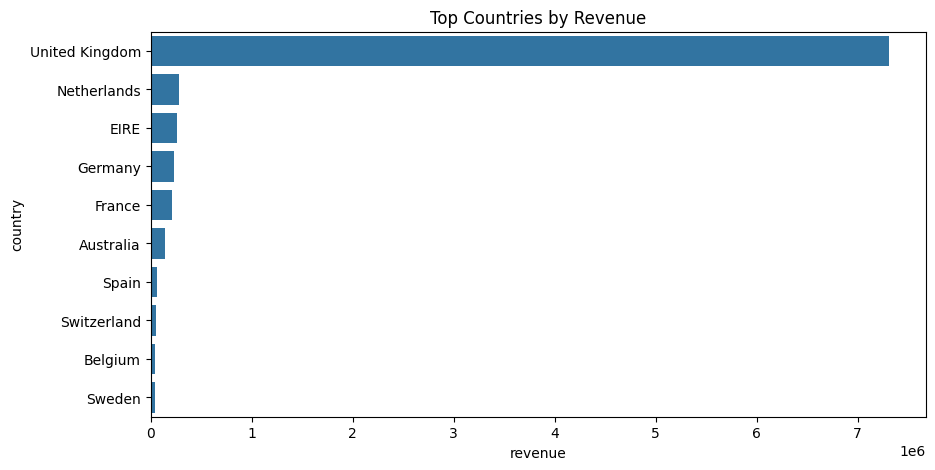

In [9]:
### Top Countries by Revenue Visualization
df_country = df_country.sort_values(by="revenue", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x="revenue", y="country", data=df_country.head(10))

plt.title("Top Countries by Revenue")
plt.show()

In [10]:
### Top 10 Products by Quantity Sold
query = """
SELECT Description, SUM(Quantity) AS TotalSold
FROM retail_transactions
GROUP BY Description
ORDER BY TotalSold DESC
LIMIT 10
"""

df_products = pd.read_sql(query, conn)
df_products

C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\1942305422.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query, conn)


,description,totalsold
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
3,JUMBO BAG RED RETROSPOT,46181
4,WHITE HANGING HEART T-LIGHT HOLDER,36725
5,ASSORTED COLOUR BIRD ORNAMENT,35362
6,PACK OF 72 RETROSPOT CAKE CASES,33693
7,POPCORN HOLDER,30931
8,RABBIT NIGHT LIGHT,27202
9,MINI PAINT SET VINTAGE,26076


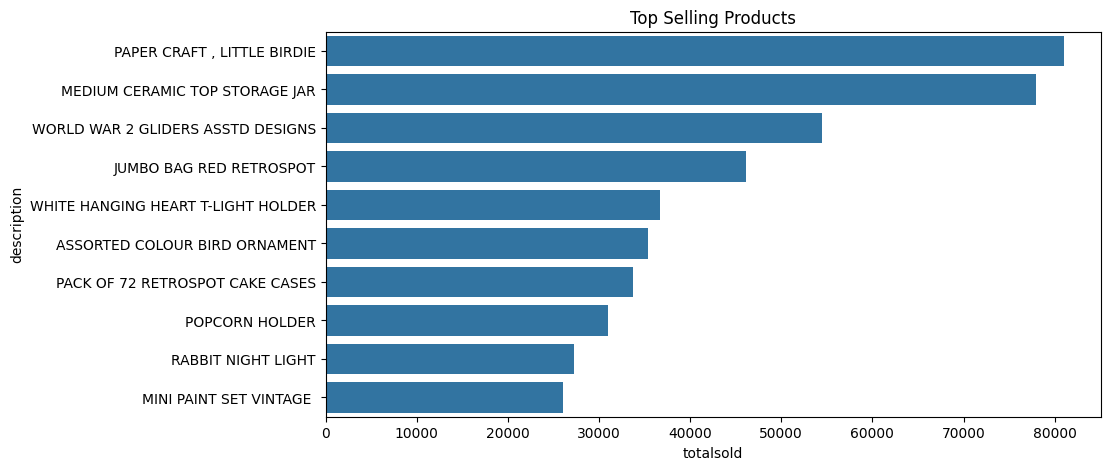

In [11]:
### Top Selling Products Visualization
plt.figure(figsize=(10,5))
sns.barplot(x="totalsold", y="description", data=df_products)

plt.title("Top Selling Products")
plt.show()

In [12]:
### Top 10 Products by Revenue
query = """
SELECT Description, SUM(Quantity * UnitPrice) AS TotalRevenue
FROM retail_transactions
GROUP BY Description
ORDER BY TotalRevenue DESC
LIMIT 10
"""

df_products_revenue = pd.read_sql(query, conn)
print("Top Products by Revenue:")
df_products_revenue

Top Products by Revenue:


C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\4184106663.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products_revenue = pd.read_sql(query, conn)


,description,totalrevenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\1288532211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="totalrevenue", y="description", data=df_products_revenue, palette="viridis")


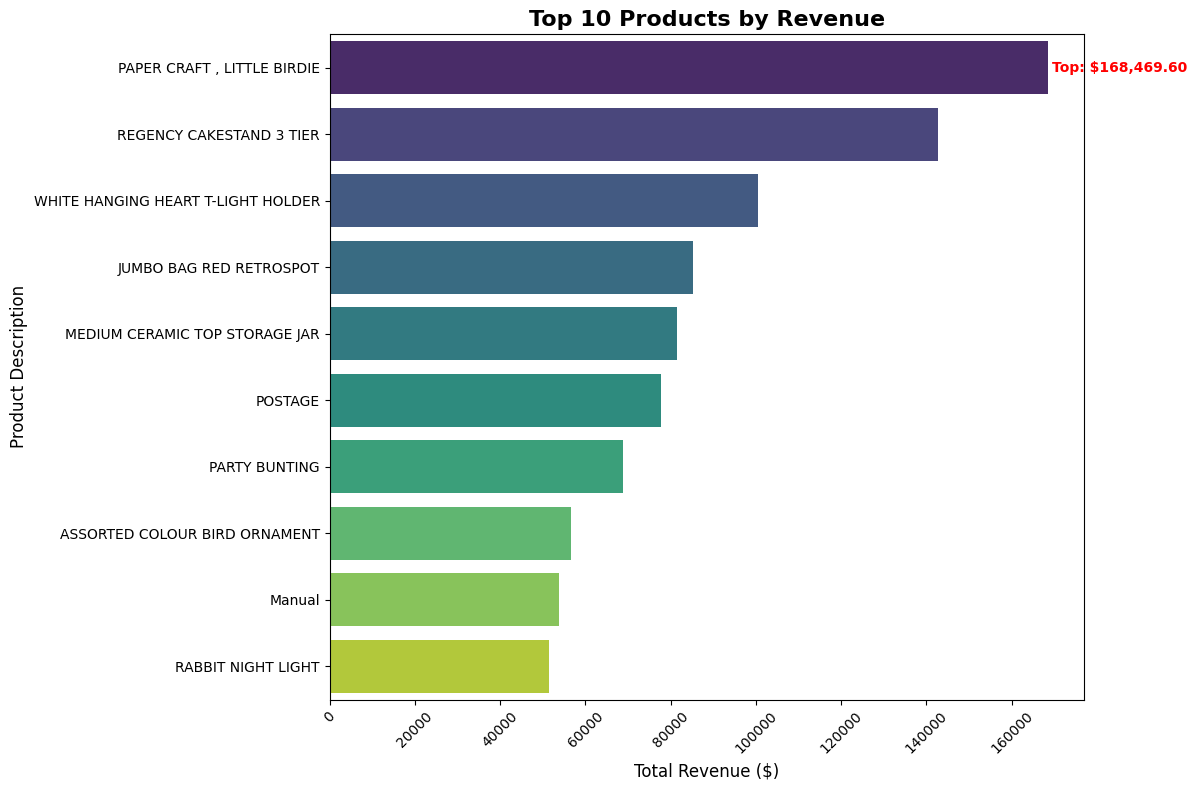

In [13]:
# Visualize top products by revenue
plt.figure(figsize=(12,8))
sns.barplot(x="totalrevenue", y="description", data=df_products_revenue, palette="viridis")

plt.title("Top 10 Products by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Total Revenue ($)", fontsize=12)
plt.ylabel("Product Description", fontsize=12)
plt.xticks(rotation=45)

# Highlight the top product
plt.text(df_products_revenue['totalrevenue'].iloc[0] + 1000, 0,
         f'Top: ${df_products_revenue["totalrevenue"].iloc[0]:,.2f}',
         ha='left', va='center', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

Top Selling Product

In [14]:
### Top Customers by Revenue
top_customers = df.groupby("customerid")["revenue"].sum().sort_values(ascending=False)
top_customers.head(10)

customerid
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: revenue, dtype: float64

In [16]:
# Find country of top customer (14646.0)
query = """
SELECT DISTINCT CustomerID, Country
FROM retail_transactions
WHERE CustomerID = 14646.0
"""

top_customer_country = pd.read_sql(query, conn)
print("Top Customer Country:")
print(f"Customer ID: {top_customer_country['customerid'].iloc[0]}")
print(f"Country: {top_customer_country['country'].iloc[0]}")
print(f"Total Revenue: ${280206.02:,.2f}")

Top Customer Country:
Customer ID: 14646.0
Country: Netherlands
Total Revenue: $280,206.02


C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\3869268721.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_customer_country = pd.read_sql(query, conn)


In [17]:
# Get top 10 customers with their countries and revenue
top_10_customers = top_customers.head(10).reset_index()
top_10_ids = tuple(top_10_customers['customerid'].astype(str).tolist())

query = f"""
SELECT CustomerID, Country, SUM(Quantity * UnitPrice) AS TotalRevenue
FROM retail_transactions
WHERE CustomerID IN {top_10_ids}
GROUP BY CustomerID, Country
ORDER BY TotalRevenue DESC
"""

top_10_with_countries = pd.read_sql(query, conn)
print("Top 10 Customers by Revenue with Countries:")
top_10_with_countries

Top 10 Customers by Revenue with Countries:


C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\1012121793.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_10_with_countries = pd.read_sql(query, conn)


,customerid,country,totalrevenue
0,14646.0,Netherlands,280206.02
1,18102.0,United Kingdom,259657.30
2,17450.0,United Kingdom,194550.79
3,16446.0,United Kingdom,168472.50
4,14911.0,EIRE,143825.06
5,12415.0,Australia,124914.53
6,14156.0,EIRE,117379.63
7,17511.0,United Kingdom,91062.38
8,16029.0,United Kingdom,81024.84
9,12346.0,United Kingdom,77183.60


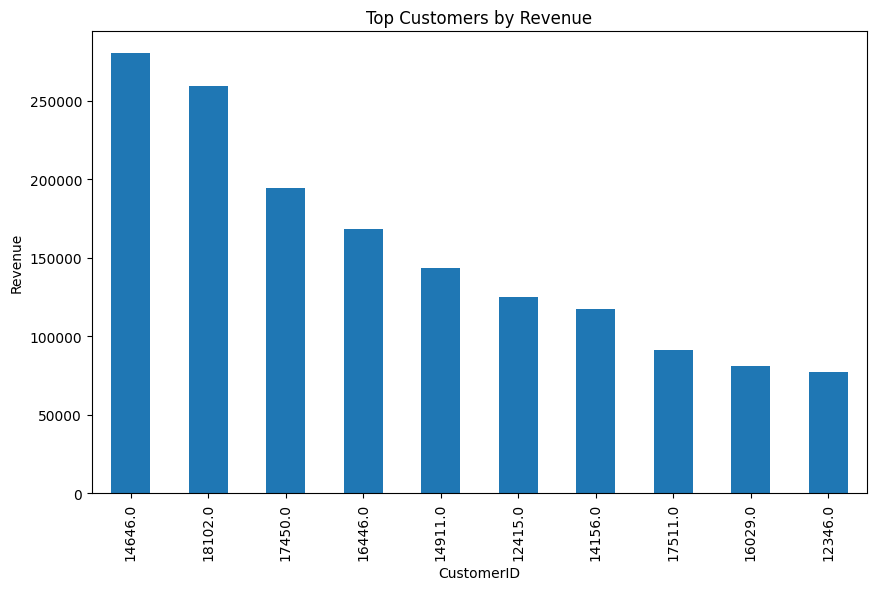

In [18]:
### Top Customers by Revenue Visualization
top_customers.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Revenue")
plt.show()

In [19]:
# Analyze products bought by top customers
query = f"""
SELECT CustomerID, Description, SUM(Quantity) as TotalQuantity, SUM(Quantity * UnitPrice) as TotalRevenue
FROM retail_transactions
WHERE CustomerID IN {top_10_ids}
GROUP BY CustomerID, Description
ORDER BY CustomerID, TotalRevenue DESC
"""

customer_products = pd.read_sql(query, conn)

# Show top products for each top customer
print("Top Products Purchased by Top 10 Customers:")
for customer_id in top_10_customers['customerid']:
    customer_data = customer_products[customer_products['customerid'] == customer_id]
    top_products = customer_data.head(3)  # Top 3 products per customer
    if not top_products.empty:
        print(f"\nCustomer {customer_id}:")
        for _, product in top_products.iterrows():
            print(f"  - {product['description'][:50]}...: {product['totalquantity']} units, ${product['totalrevenue']:.2f}")

Top Products Purchased by Top 10 Customers:

Customer 14646.0:
  - RABBIT NIGHT LIGHT...: 4801 units, $9568.48
  - ROUND SNACK BOXES SET OF4 WOODLAND ...: 3120 units, $7956.00
  - SPACEBOY LUNCH BOX ...: 4492 units, $7415.40

Customer 18102.0:
  - VINTAGE UNION JACK MEMOBOARD...: 2600 units, $16592.08
  - WOOD BLACK BOARD ANT WHITE FINISH...: 3205 units, $15351.00
  - CREAM HEART CARD HOLDER...: 5946 units, $14089.90

Customer 17450.0:
  - HEART OF WICKER LARGE...: 4282 units, $13459.64
  - WHITE HANGING HEART T-LIGHT HOLDER...: 4114 units, $13253.84
  - SET OF TEA COFFEE SUGAR TINS PANTRY...: 2109 units, $10566.73

Customer 16446.0:
  - PAPER CRAFT , LITTLE BIRDIE...: 80995 units, $168469.60
  - PANTRY SCRUBBING BRUSH...: 1 units, $1.65
  - PANTRY PASTRY BRUSH...: 1 units, $1.25

Customer 14911.0:
  - CARRIAGE...: 84 units, $4175.00
  - REGENCY CAKESTAND 3 TIER...: 352 units, $4043.70
  - Manual...: 2 units, $3374.34

Customer 12415.0:
  - RABBIT NIGHT LIGHT...: 1536 units, $2749.44
 

C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\2651314863.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_products = pd.read_sql(query, conn)


In [ ]:
# Total unique customers (Active Customers)
active_customers = df['customerid'].nunique()

# Average Order Value (AOV)
aov = df['revenue'].sum() / df['invoiceno'].nunique()

# Repeat Customers
repeat_customers = df.groupby('customerid')['invoiceno'].nunique()
repeat_customers_count = (repeat_customers > 1).sum()

# Repeat Rate (%)
repeat_rate = (repeat_customers_count / active_customers) * 100

# Print results
print("Active Customers:", active_customers)
print("Average Order Value (AOV):", round(aov, 2))
print("Repeat Customers:", repeat_customers_count)
print("Repeat Rate (%):", round(repeat_rate, 2))

In [20]:
# Find top product by revenue for each country
query = """
SELECT Country, Description, SUM(Quantity * UnitPrice) AS TotalRevenue
FROM retail_transactions
GROUP BY Country, Description
ORDER BY Country, TotalRevenue DESC
"""

country_product_revenue = pd.read_sql(query, conn)

# Get the top product for each country
print("Top Revenue-Generating Product in Each Country:")
countries = country_product_revenue['country'].unique()

for country in sorted(countries):
    country_data = country_product_revenue[country_product_revenue['country'] == country]
    top_product = country_data.iloc[0]  # First row is already sorted by revenue desc
    print(f"\n{country}:")
    print(f"  Top Product: {top_product['description'][:60]}...")
    print(f"  Revenue: ${top_product['totalrevenue']:,.2f}")

# Also show overall top countries with their top products
print("\n" + "="*60)
print("TOP 10 COUNTRIES WITH THEIR BEST-SELLING PRODUCTS:")
print("="*60)

top_countries = df_country.head(10)['country'].tolist()
for country in top_countries:
    if country in countries:
        country_data = country_product_revenue[country_product_revenue['country'] == country]
        top_product = country_data.iloc[0]
        print(f"\n{country}:")
        print(f"  Top Product: {top_product['description'][:50]}...")
        print(f"  Revenue: ${top_product['totalrevenue']:,.2f}")
        # Show country's total revenue for context
        country_total = df_country[df_country['country'] == country]['revenue'].iloc[0]
        product_percentage = (top_product['totalrevenue'] / country_total) * 100
        print(f"  Percentage of Country Revenue: {product_percentage:.1f}%")

C:\Users\jayde\AppData\Local\Temp\ipykernel_14568\2528119881.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  country_product_revenue = pd.read_sql(query, conn)


Top Revenue-Generating Product in Each Country:

Australia:
  Top Product: RABBIT NIGHT LIGHT...
  Revenue: $3,375.84

Austria:
  Top Product: POSTAGE...
  Revenue: $1,456.00

Bahrain:
  Top Product: ICE CREAM SUNDAE LIP GLOSS...
  Revenue: $120.00

Belgium:
  Top Product: POSTAGE...
  Revenue: $4,269.00

Brazil:
  Top Product: REGENCY CAKESTAND 3 TIER...
  Revenue: $175.20

Canada:
  Top Product: POSTAGE...
  Revenue: $550.94

Channel Islands:
  Top Product: REGENCY CAKESTAND 3 TIER...
  Revenue: $517.80

Cyprus:
  Top Product: RUSTIC  SEVENTEEN DRAWER SIDEBOARD...
  Revenue: $580.00

Czech Republic:
  Top Product: ROUND SNACK BOXES SET OF4 WOODLAND ...
  Revenue: $70.80

Denmark:
  Top Product: POSTAGE...
  Revenue: $744.00

EIRE:
  Top Product: REGENCY CAKESTAND 3 TIER...
  Revenue: $7,388.55

European Community:
  Top Product: POSTAGE...
  Revenue: $141.00

Finland:
  Top Product: POSTAGE...
  Revenue: $3,650.00

France:
  Top Product: POSTAGE...
  Revenue: $15,454.00

Germany:
  T

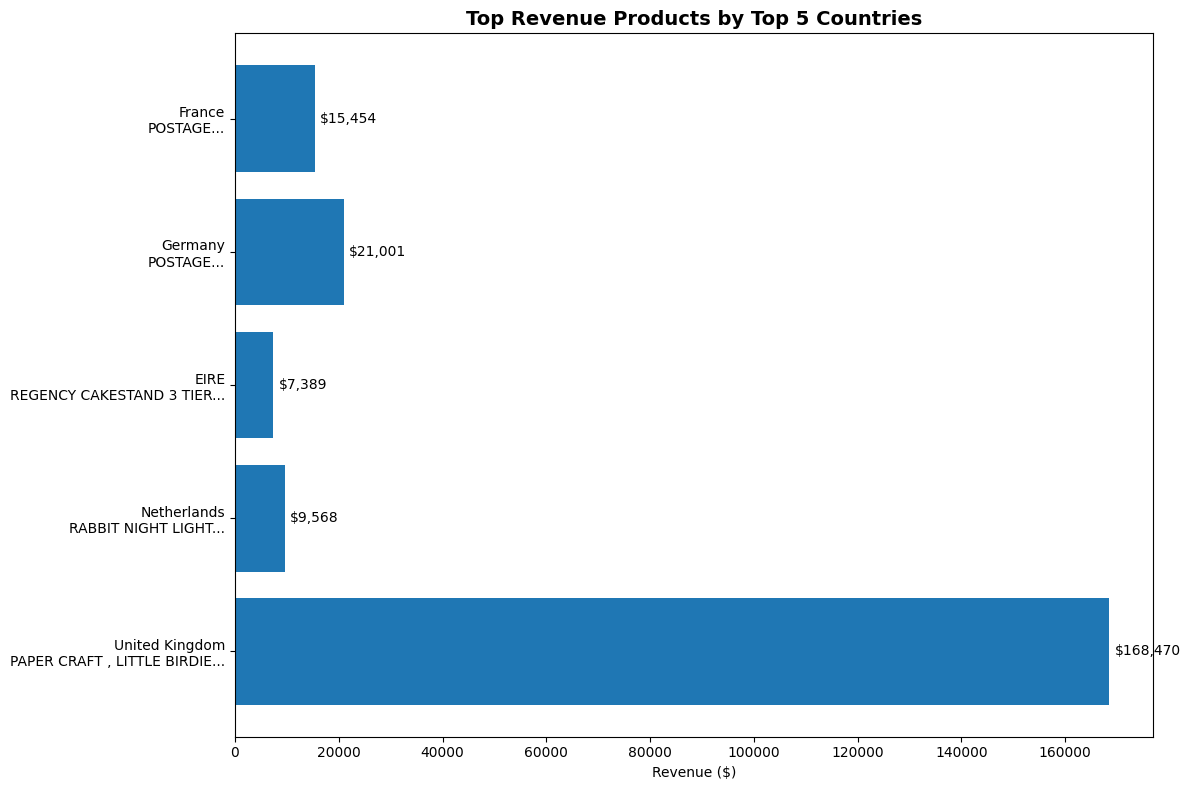

In [21]:
# Create visualization for top countries and their best products
top_countries_data = []
for country in top_countries[:5]:  # Top 5 countries for cleaner visualization
    if country in countries:
        country_data = country_product_revenue[country_product_revenue['country'] == country]
        top_product = country_data.iloc[0]
        top_countries_data.append({
            'country': country,
            'product': top_product['description'][:30] + "...",
            'revenue': top_product['totalrevenue']
        })

top_countries_df = pd.DataFrame(top_countries_data)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_countries_df)), top_countries_df['revenue'])
plt.yticks(range(len(top_countries_df)), [f"{row['country']}\n{row['product']}" for _, row in top_countries_df.iterrows()])
plt.xlabel('Revenue ($)')
plt.title('Top Revenue Products by Top 5 Countries', fontsize=14, fontweight='bold')

# Add value labels on bars
for i, (bar, revenue) in enumerate(zip(bars, top_countries_df['revenue'])):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'${revenue:,.0f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [22]:
# Find customers with most orders (highest reorder frequency)
customer_order_frequency = df.groupby('customerid')['invoiceno'].nunique().sort_values(ascending=False)

print("Top 10 Customers by Order Frequency (Most Reorders):")
top_reorder_customers = customer_order_frequency.head(10)
for i, (customer_id, order_count) in enumerate(top_reorder_customers.items(), 1):
    # Get customer's country and total revenue
    customer_data = df[df['customerid'] == customer_id]
    country = customer_data['country'].iloc[0]
    total_revenue = customer_data['revenue'].sum()
    print(f"{i}. Customer {customer_id} ({country}): {order_count} orders, ${total_revenue:,.2f} total revenue")

# Also show average order value for these frequent customers
print("\nAverage Order Value for Top Reorder Customers:")
for customer_id in top_reorder_customers.index[:5]:  # Top 5
    customer_orders = df[df['customerid'] == customer_id].groupby('invoiceno')['revenue'].sum()
    avg_order_value = customer_orders.mean()
    print(f"Customer {customer_id}: ${avg_order_value:.2f} average per order")

Top 10 Customers by Order Frequency (Most Reorders):
1. Customer 12748.0 (United Kingdom): 210 orders, $33,719.73 total revenue
2. Customer 14911.0 (EIRE): 201 orders, $143,825.06 total revenue
3. Customer 17841.0 (United Kingdom): 124 orders, $40,991.57 total revenue
4. Customer 13089.0 (United Kingdom): 97 orders, $58,825.83 total revenue
5. Customer 14606.0 (United Kingdom): 93 orders, $12,156.65 total revenue
6. Customer 15311.0 (United Kingdom): 91 orders, $60,767.90 total revenue
7. Customer 12971.0 (United Kingdom): 86 orders, $11,189.91 total revenue
8. Customer 14646.0 (Netherlands): 74 orders, $280,206.02 total revenue
9. Customer 16029.0 (United Kingdom): 63 orders, $81,024.84 total revenue
10. Customer 13408.0 (United Kingdom): 62 orders, $28,117.04 total revenue

Average Order Value for Top Reorder Customers:
Customer 12748.0: $160.57 average per order
Customer 14911.0: $715.55 average per order
Customer 17841.0: $330.58 average per order
Customer 13089.0: $606.45 average 

<Figure size 1200x800 with 0 Axes>

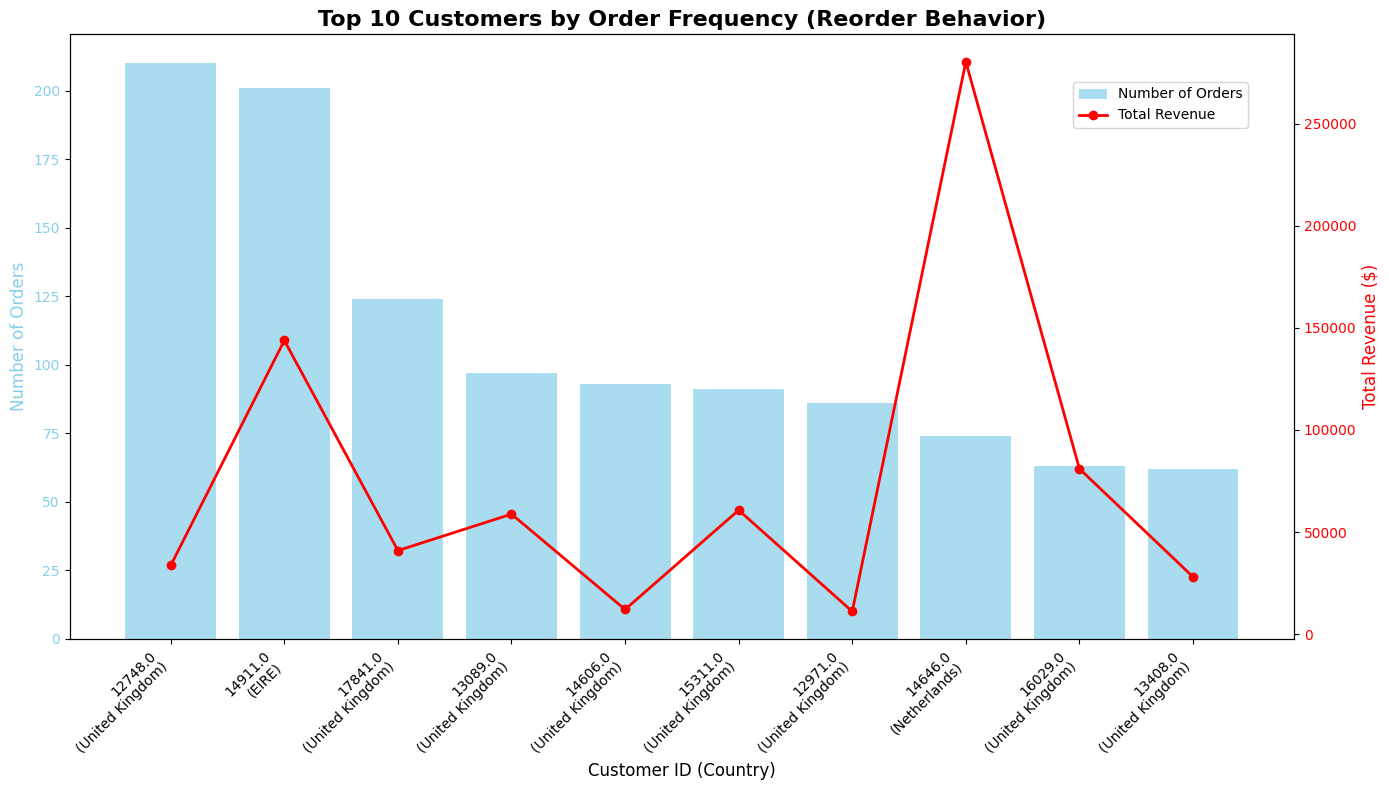

In [23]:
# Visualize top reorder customers
plt.figure(figsize=(12, 8))

# Create data for top 10 reorder customers
reorder_data = []
for customer_id in top_reorder_customers.index[:10]:
    customer_data = df[df['customerid'] == customer_id]
    country = customer_data['country'].iloc[0]
    total_revenue = customer_data['revenue'].sum()
    reorder_data.append({
        'customer': f"{customer_id}\n({country})",
        'orders': customer_order_frequency[customer_id],
        'revenue': total_revenue
    })

reorder_df = pd.DataFrame(reorder_data)

# Create dual-axis plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar plot for number of orders
bars = ax1.bar(range(len(reorder_df)), reorder_df['orders'], color='skyblue', alpha=0.7, label='Number of Orders')
ax1.set_xlabel('Customer ID (Country)', fontsize=12)
ax1.set_ylabel('Number of Orders', color='skyblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line plot for revenue
ax2 = ax1.twinx()
line = ax2.plot(range(len(reorder_df)), reorder_df['revenue'], color='red', marker='o', linewidth=2, label='Total Revenue')
ax2.set_ylabel('Total Revenue ($)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Set x-ticks
ax1.set_xticks(range(len(reorder_df)))
ax1.set_xticklabels(reorder_df['customer'], rotation=45, ha='right')

# Title and legend
plt.title('Top 10 Customers by Order Frequency (Reorder Behavior)', fontsize=16, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

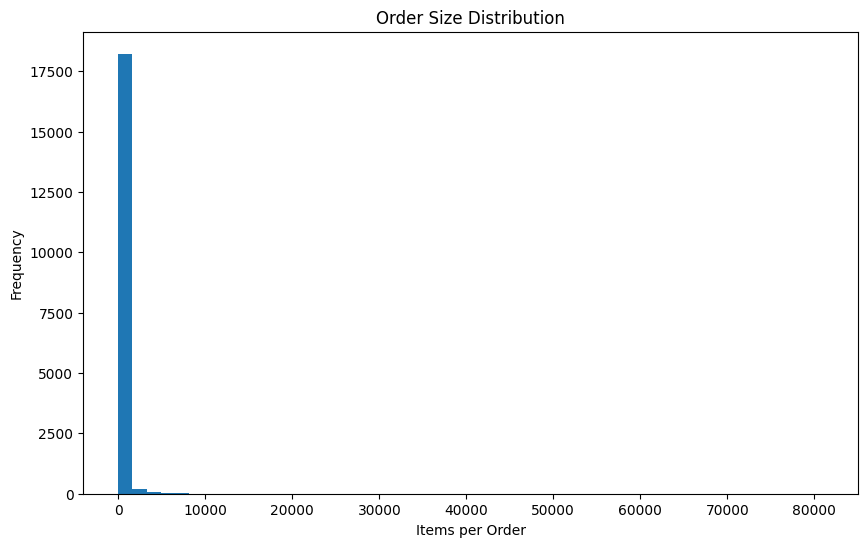

In [24]:
### Order Size Distribution
order_sizes = df.groupby("invoiceno")["quantity"].sum()

plt.figure(figsize=(10,6))
plt.hist(order_sizes, bins=50)

plt.title("Order Size Distribution")
plt.xlabel("Items per Order")
plt.ylabel("Frequency")

plt.show()

In [25]:
### Average Order Value
order_value = df.groupby("invoiceno")["revenue"].sum()
avg_order_value = order_value.mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 480.7621873111782


In [26]:
print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'revenue'],
      dtype='str')


In [27]:
### Highest Revenue per Unit Products
df.groupby("description").apply(
    lambda x: x["revenue"].sum() / x["quantity"].sum()
).sort_values(ascending=False).head(10)

description
DOTCOM POSTAGE                        744.147500
PICNIC BASKET WICKER 60 PIECES        649.500000
RUSTIC  SEVENTEEN DRAWER SIDEBOARD    154.714286
REGENCY MIRROR WITH SHUTTERS          153.000000
VINTAGE BLUE KITCHEN CABINET          141.730769
VINTAGE RED KITCHEN CABINET           135.416667
CHEST NATURAL WOOD 20 DRAWERS         114.375000
LOVE SEAT ANTIQUE WHITE METAL         107.068966
SCHOOL DESK AND CHAIR                  63.144737
DECORATIVE HANGING SHELVING UNIT       59.950000
dtype: float64

In [28]:
### Most Frequently Purchased Products
df.groupby("description")["invoiceno"].nunique().sort_values(ascending=False).head(10)

description
WHITE HANGING HEART T-LIGHT HOLDER    1971
REGENCY CAKESTAND 3 TIER              1704
JUMBO BAG RED RETROSPOT               1600
PARTY BUNTING                         1380
ASSORTED COLOUR BIRD ORNAMENT         1375
LUNCH BAG RED RETROSPOT               1288
SET OF 3 CAKE TINS PANTRY DESIGN      1146
POSTAGE                               1099
LUNCH BAG  BLACK SKULL.               1052
PACK OF 72 RETROSPOT CAKE CASES       1029
Name: invoiceno, dtype: int64

In [29]:
### Converting Invoice Date to Datetime Format
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

In [30]:
### Extracting Month from Invoice Date
df["month"] = df["invoicedate"].dt.to_period("M")

In [31]:
### Monthly Revenue Calculation
monthly_revenue = df.groupby("month")["revenue"].sum()
monthly_revenue

month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: revenue, dtype: float64

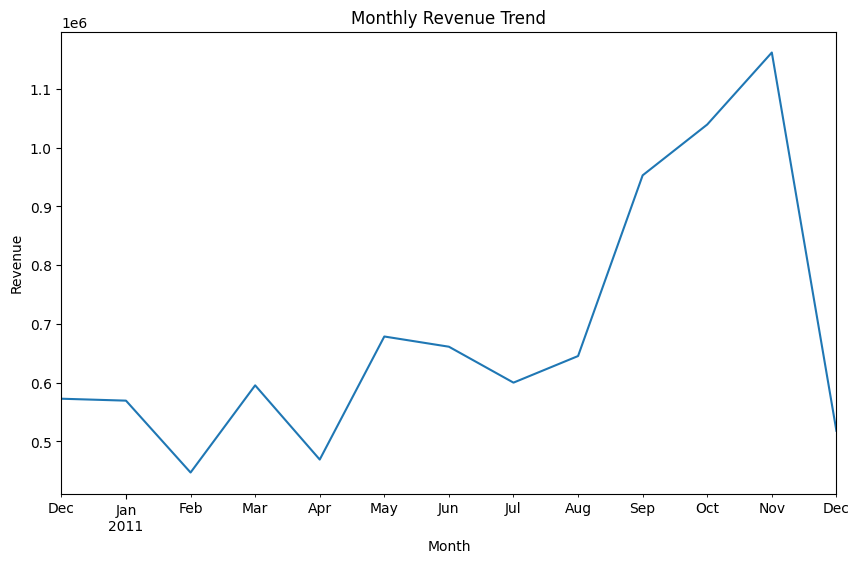

In [32]:
### Monthly Revenue Trend Visualization
monthly_revenue.plot(figsize=(10,6))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [33]:
### Revenue by Day of the Week
df["day"] = df["invoicedate"].dt.day_name()
df.groupby("day")["revenue"].sum()

day
Friday       1485917.401
Monday       1367146.411
Sunday        792514.221
Thursday     1976859.070
Tuesday      1700634.631
Wednesday    1588336.170
Name: revenue, dtype: float64

In [34]:
### Revenue by Hour of the Day
df["hour"] = df["invoicedate"].dt.hour
df.groupby("hour")["revenue"].sum().sort_values(ascending=False)

hour
12    1378571.480
10    1261192.571
13    1173264.750
11    1104558.750
14     995629.371
15     966191.750
9      842605.171
16     468885.800
8      282115.630
17     234413.521
18     104954.430
19      49028.460
7       31059.210
20      18932.760
6           4.250
Name: revenue, dtype: float64

In [35]:
### Average Revenue per Country
country_avg_revenue = df.groupby("country")["revenue"].mean().sort_values(ascending=False)
country_avg_revenue

country
Netherlands             120.798282
Australia               116.895620
Japan                   116.561900
Singapore                95.852658
Sweden                   85.096075
Denmark                  49.882474
Lithuania                47.458857
Lebanon                  37.641778
EIRE                     36.687745
Brazil                   35.737500
Norway                   33.736418
Czech Republic           33.069600
Finland                  32.913985
Greece                   32.831172
Bahrain                  32.258824
Switzerland              30.642752
Israel                   29.119718
United Arab Emirates     27.974706
Channel Islands          27.340160
Austria                  25.624824
Germany                  25.311562
France                   25.056827
Spain                    24.779521
Malta                    24.335625
Canada                   24.280662
Iceland                  23.681319
Italy                    23.064960
Portugal                 22.872702
Poland      

In [36]:
### Average Revenue per Country
df.groupby("country")["customerid"].nunique().sort_values(ascending=False)

country
United Kingdom          3921
Germany                   94
France                    87
Spain                     30
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     14
Finland                   12
Austria                   11
Norway                    10
Australia                  9
Denmark                    9
Netherlands                9
Channel Islands            9
Japan                      8
Sweden                     8
Cyprus                     8
Poland                     6
Unspecified                4
USA                        4
Canada                     4
Greece                     4
Israel                     3
EIRE                       3
United Arab Emirates       2
Bahrain                    2
Malta                      2
Brazil                     1
Lebanon                    1
Iceland                    1
Czech Republic             1
European Community         1
Saudi Arabia               1
RSA   

In [37]:
### Top Products by Quantity Sold
top_quantity = df.groupby("description")["quantity"].sum().sort_values(ascending=False)

In [38]:
# Key Findings
print("Country with most revenue:", df_country.iloc[0]['country'], "with $", df_country.iloc[0]['revenue'])
print("Month with maximum revenue:", monthly_revenue.idxmax(), "with $", monthly_revenue.max())
print("Product with most sales (by quantity):", top_quantity.index[0], "with", top_quantity.iloc[0], "units")

Country with most revenue: United Kingdom with $ 7308391.554
Month with maximum revenue: 2011-11 with $ 1161817.38
Product with most sales (by quantity): PAPER CRAFT , LITTLE BIRDIE with 80995 units


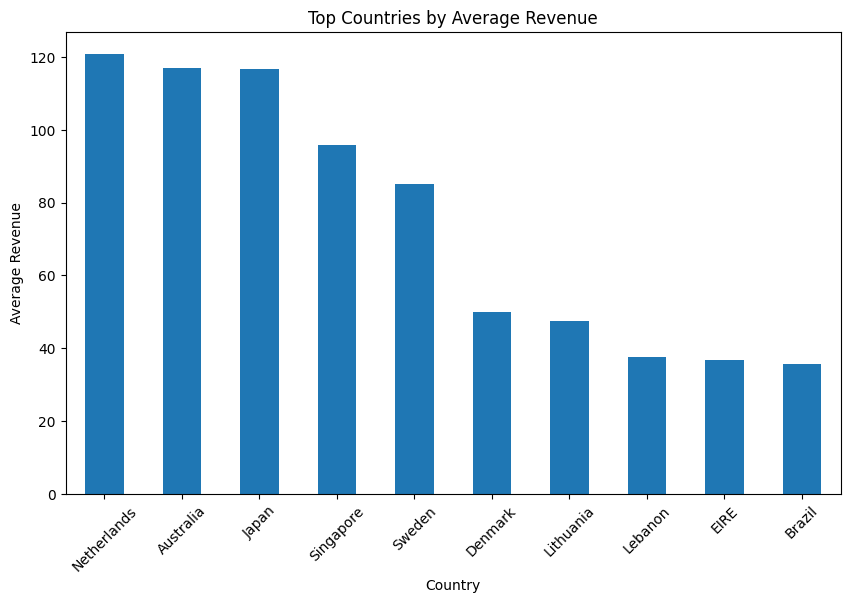

In [39]:
### Top Countries by Average Revenue Visualization
country_avg_revenue.head(10).plot(kind="bar", figsize=(10,6))
plt.title("Top Countries by Average Revenue")
plt.xlabel("Country")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()